In [11]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings
import matplotlib.pyplot as plt
import riskfolio as rp
from scipy.stats import norm


warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.4%}'.format

# Confidence level in %
confidence_level = 0.05

# Date range
start_date = '2022-10-01'
end_date = '2023-10-01'

# Tickers of assets
tickers = ['AAPL']
tickers.sort()

# Risk free rate
risk_free_rate = 0.04

# Benchmark
benchmark = "^GSPC"

[*********************100%***********************]  1 of 1 completed

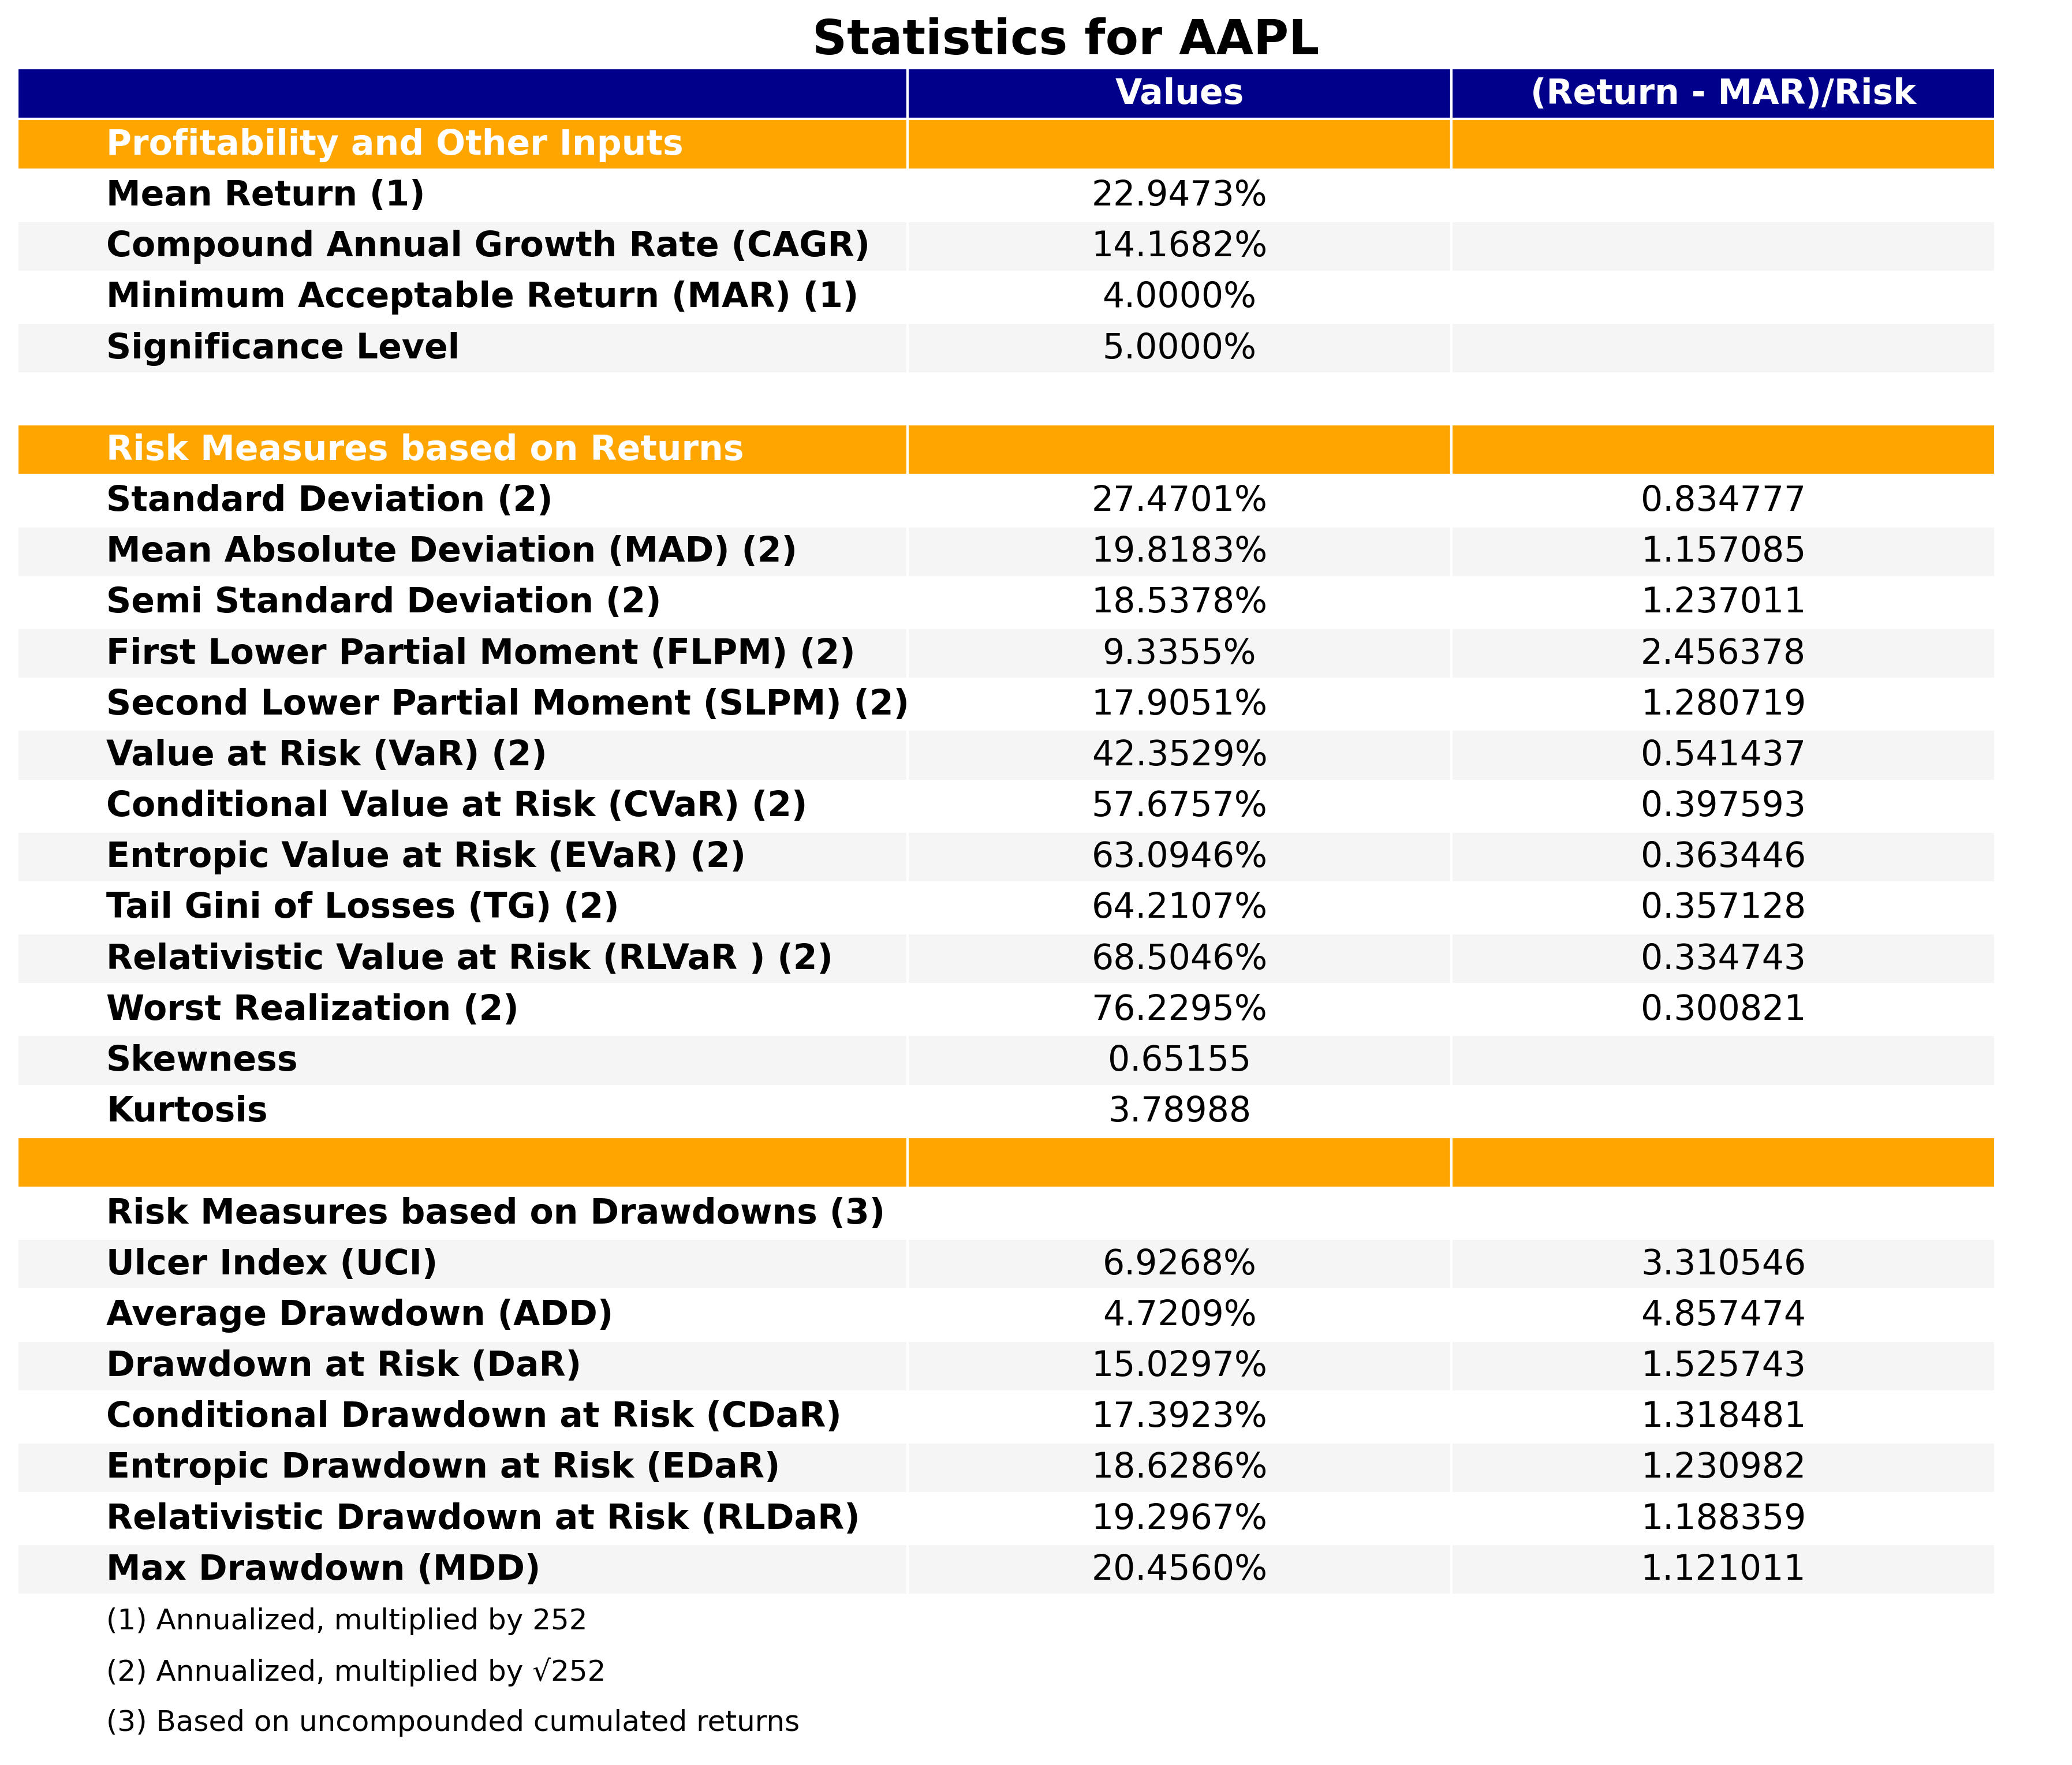

In [12]:
for ticker in tickers:
    # Fetch historical stock data
    stock_data = yf.download(ticker, start=start_date, end=end_date)

    # Calculate Arithmetic returns
    Y = stock_data['Adj Close'].pct_change().dropna()

    # Convert returns Series to DataFrame
    Y = pd.DataFrame(Y) 
    Y.rename(columns={'Adj Close': ticker}, inplace=True) # Set ticker as column name
    #display(Y.head())

    # Define weights as DataFrame
    w = pd.DataFrame(data=[[1.0]], columns=[ticker], index=[0]).T 
    #display(w.T)

    # Create a separate figure and axis for each ticker's plot
    fig, ax = plt.subplots(figsize=(12, 10), dpi=300)  # Adjust figure size

    # Plotting the basic table
    ax = rp.plot_table(returns=Y,
                   w=w,
                   MAR=risk_free_rate/252,
                   alpha=confidence_level,
                   ax=ax)

    # Adding title with ticker name
    ax.set_title(f'Statistics for {ticker}', fontsize=20, fontweight='bold')  # Increase font size and make it bold

    # Show the plot for each ticker
    plt.show()

[*********************100%***********************]  1 of 1 completed

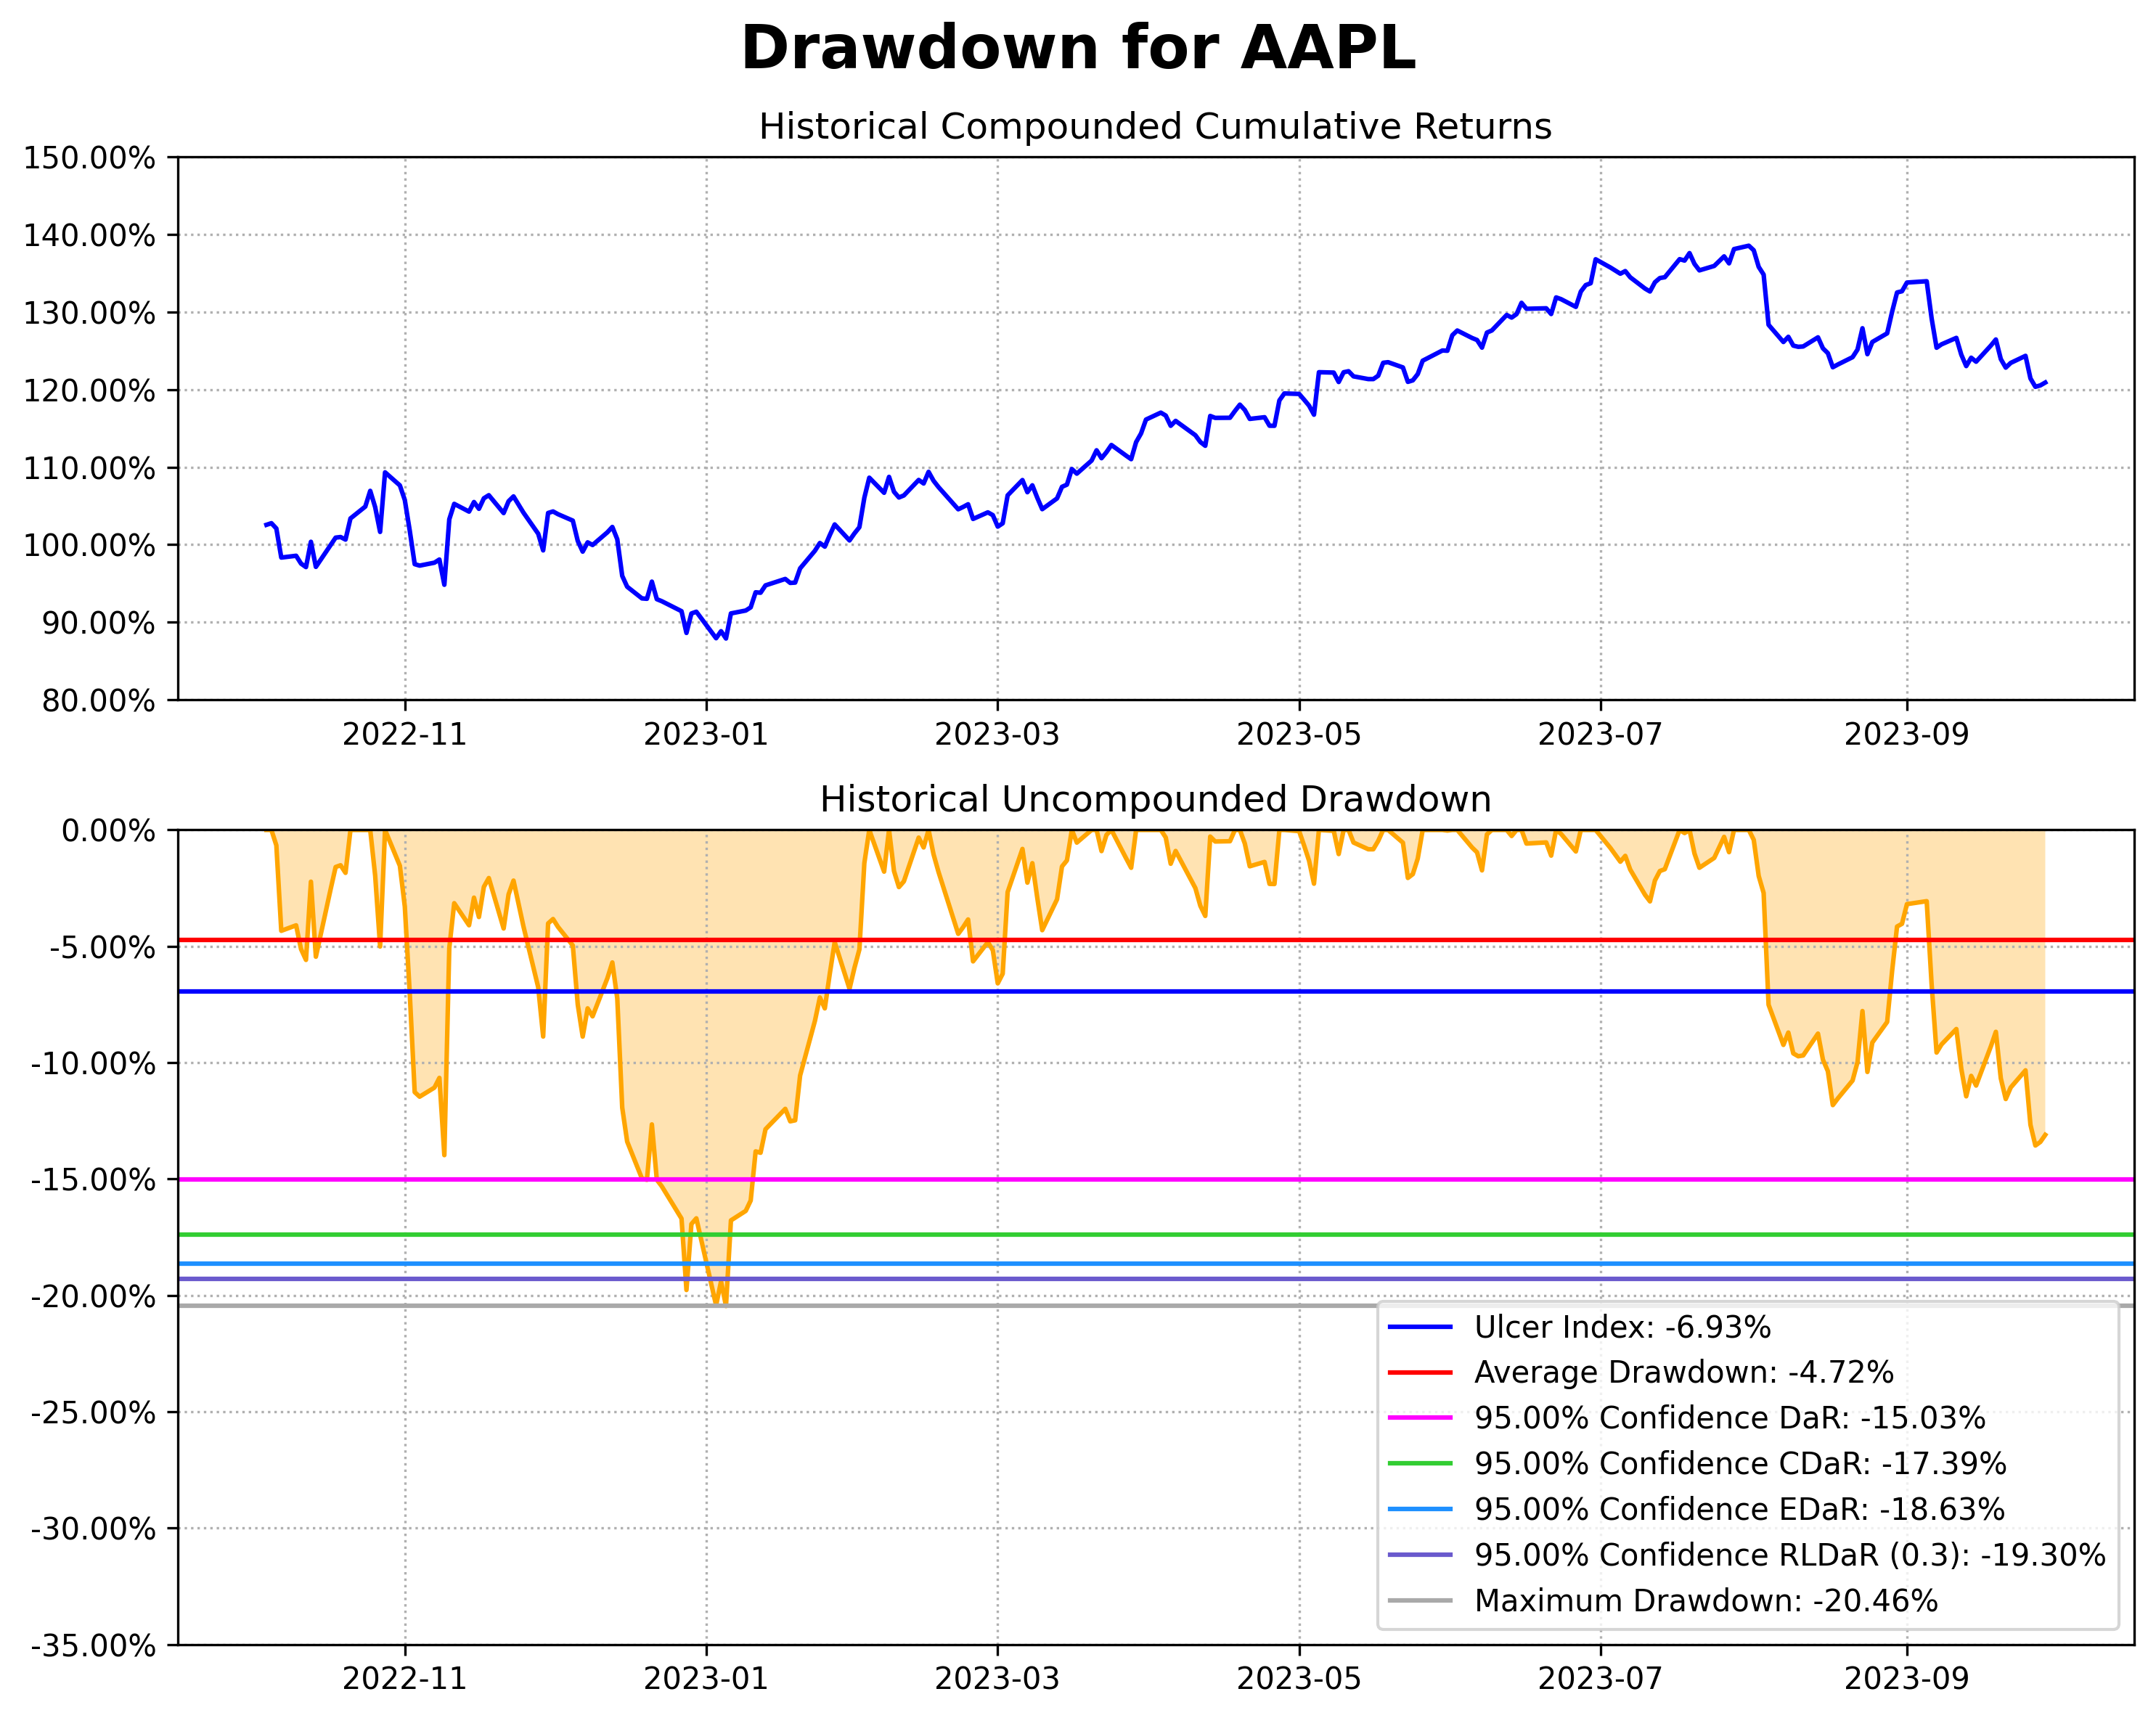

In [13]:
for ticker in tickers:
    # Fetch historical stock data
    stock_data = yf.download(ticker, start=start_date, end=end_date)

    # Calculate Arithmetic returns
    Y = stock_data['Adj Close'].pct_change().dropna()

    # Convert returns Series to DataFrame
    Y = pd.DataFrame(Y) 
    Y.rename(columns={'Adj Close': ticker}, inplace=True) # Set ticker as column name
    #display(Y.head())

    # Define weights as DataFrame
    w = pd.DataFrame(data=[[1.0]], columns=[ticker], index=[0]).T 
    #display(w.T)

    # Create a separate figure and axis for each ticker's plot
    fig, ax_draw = plt.subplots(figsize=(10,8), dpi=300)  # Adjust figure size

    # Adding title with ticker name
    fig.suptitle(f'Drawdown for {ticker}', fontsize=20, fontweight='bold')  # Increase font size and make it bold

    # Plotting the drawdown table
    ax_draw = rp.plot_drawdown(returns=Y,
                    w=w,
                    alpha=0.05,
                    height=10,
                    width=10,
                    ax=ax_draw)

    # Show the plot for each ticker
    plt.show()

[*********************100%***********************]  1 of 1 completed


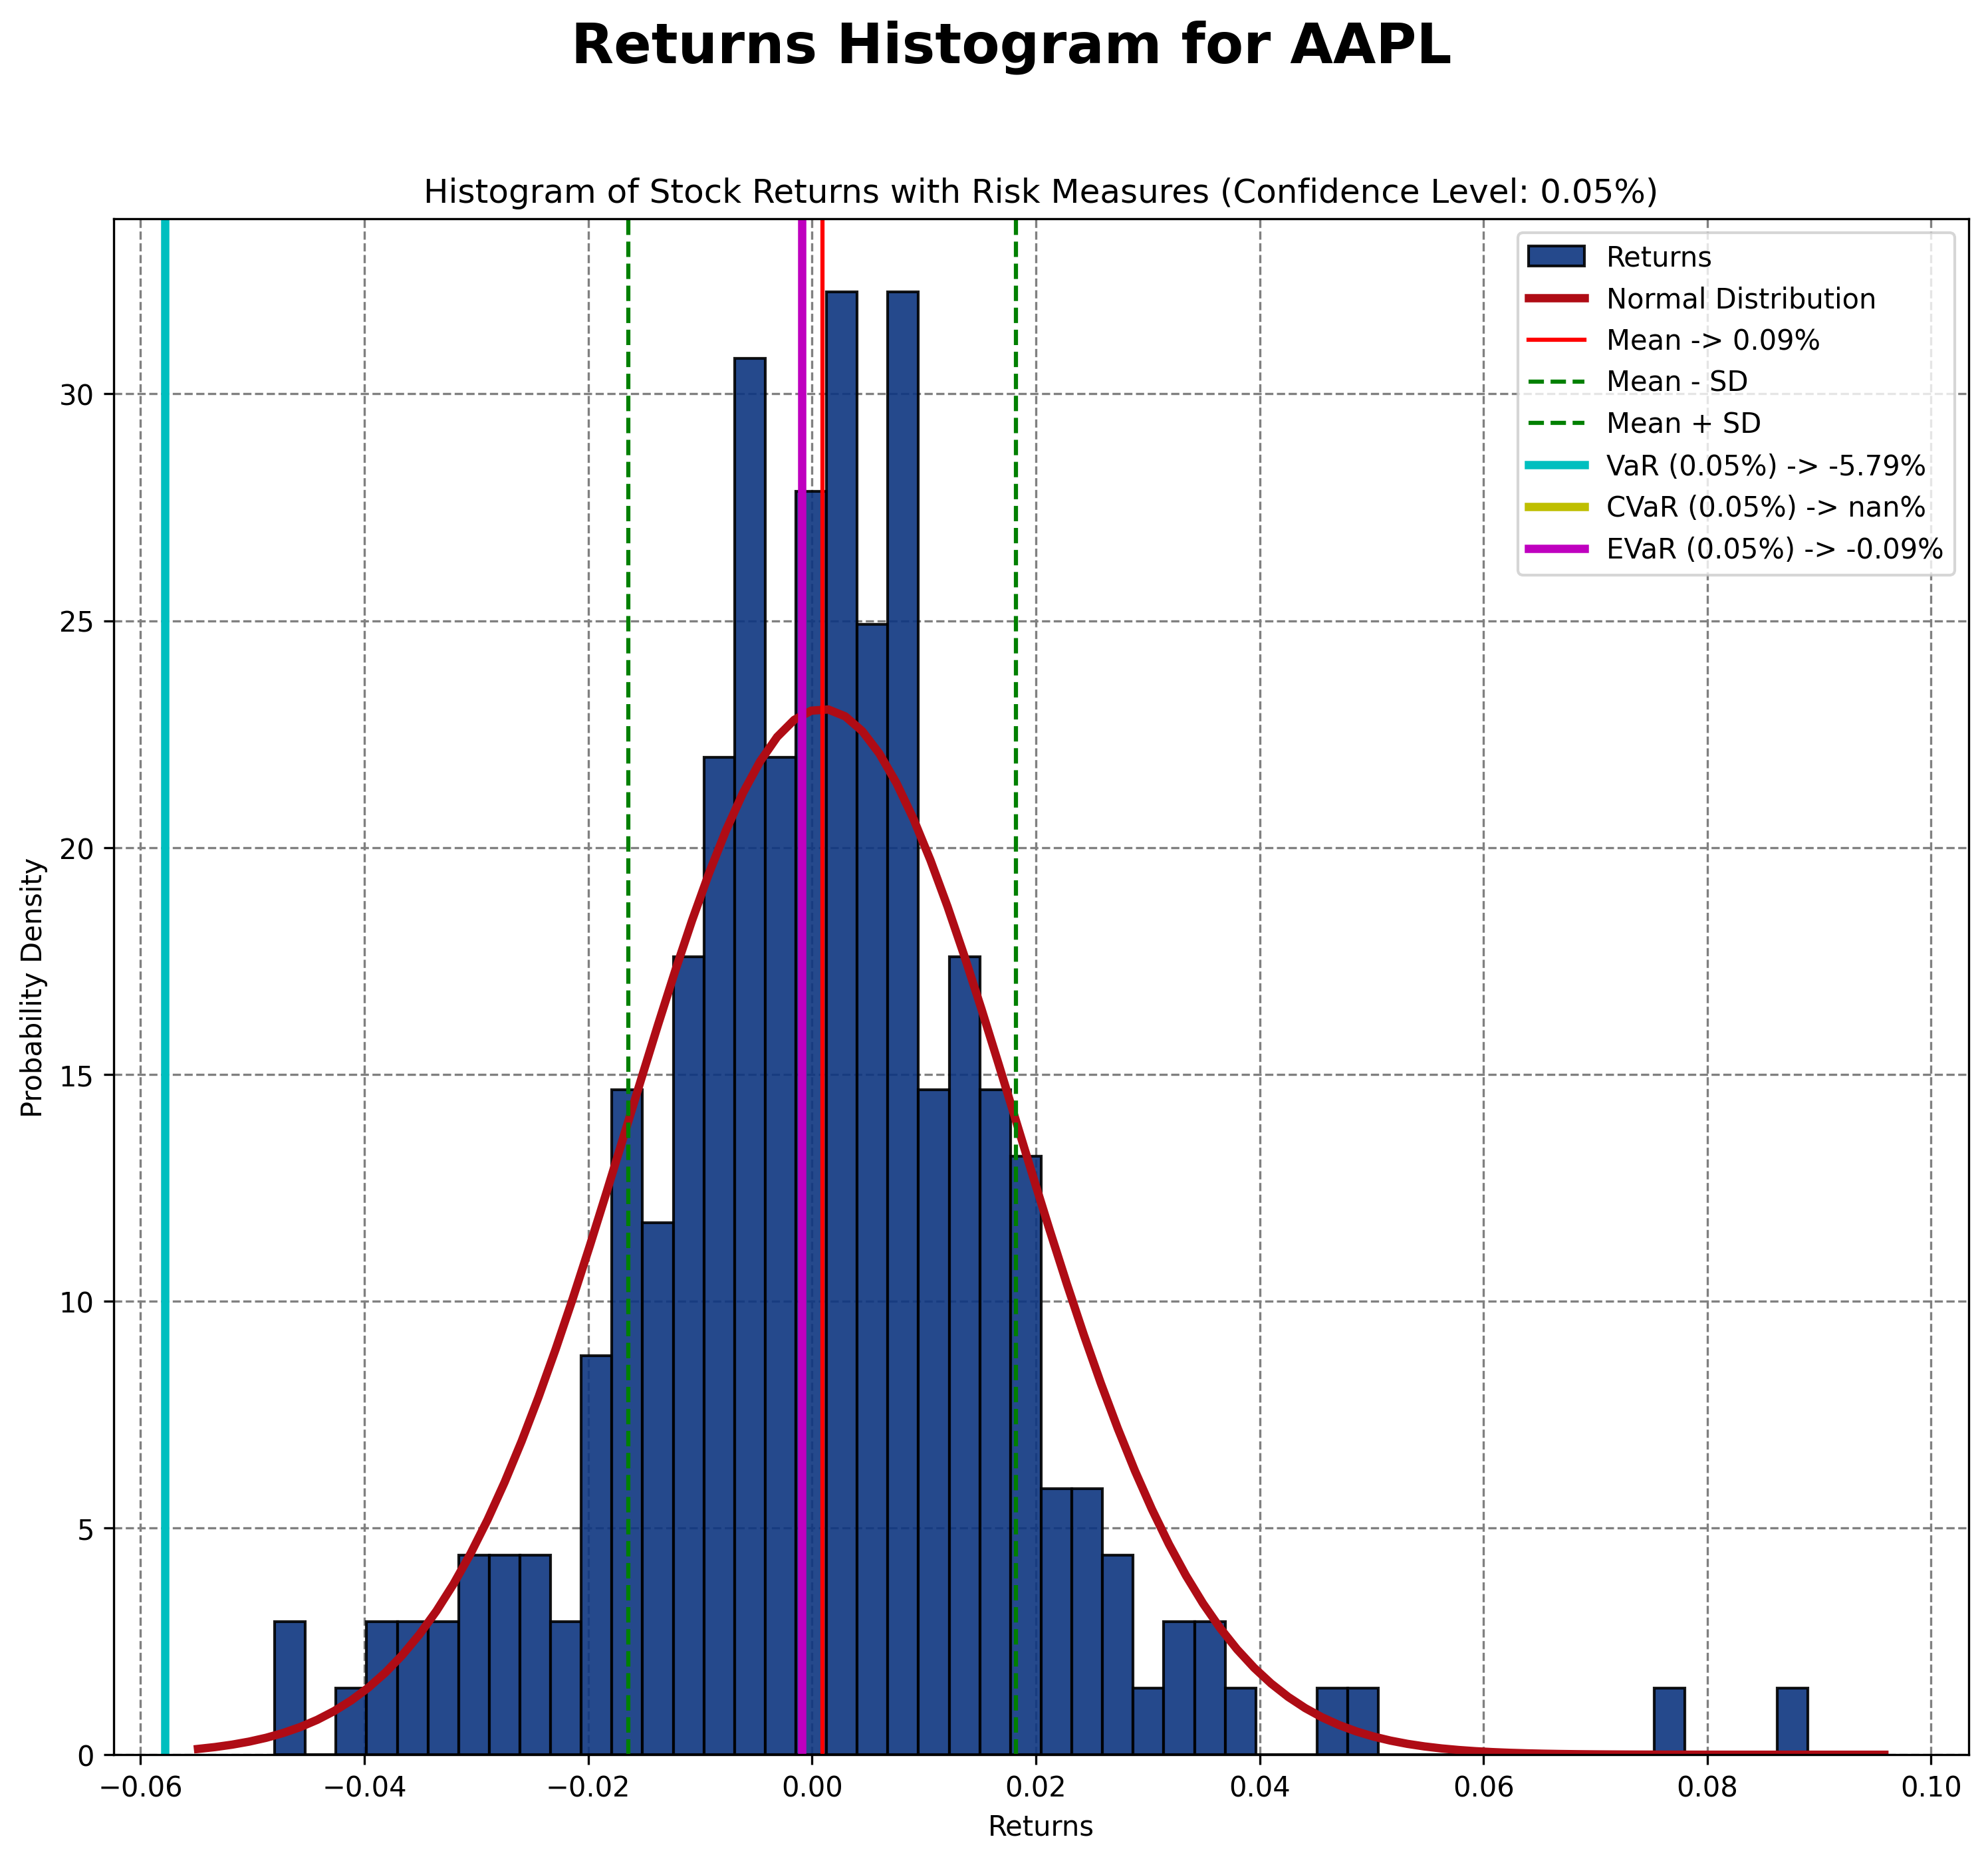

In [14]:
def calculate_gaussian_var(returns, alpha):
    """Calculate Gaussian Value-at-Risk using the variance-covariance method."""
    mu = returns.mean()
    sigma = returns.std()
    z_alpha = norm.ppf(
        1 - alpha
    )  # Percent-point function of the standard normal distribution
    gvar = -(mu + z_alpha * sigma)
    return gvar

def calculate_entropic_var(returns, alpha):
    """Calculate Entropic Value-at-Risk using the empirical distribution."""
    sorted_returns = np.sort(returns)
    n = len(sorted_returns)
    p = np.arange(1, n + 1) / n
    q = np.log(p)
    weights = np.exp(alpha * q)
    evar = -np.sum(sorted_returns * weights) / np.sum(weights)
    return evar

def calculate_conditional_var(returns, alpha):
    VaR = calculate_gaussian_var(returns, alpha)
    cvar = np.mean(returns[returns <= VaR])  # Average of losses exceeding VaR
    return cvar

for ticker in tickers:
    # Fetch historical stock data
    stock_data = yf.download(ticker, start=start_date, end=end_date)

    # Calculate Arithmetic returns
    Y = stock_data['Adj Close'].pct_change().dropna()

    # Convert returns Series to DataFrame
    Y = pd.DataFrame(Y) 
    Y.rename(columns={'Adj Close': ticker}, inplace=True) # Set ticker as column name
    #display(Y.head())

    # Define weights as DataFrame
    w = pd.DataFrame(data=[[1.0]], columns=[ticker], index=[0]).T 
    #display(w.T)

    Y = Y.squeeze()
    
    mean_return = Y.mean()
    std_dev = Y.std()
    var = -np.percentile(Y, 100 - confidence_level)
    cvar = calculate_conditional_var(Y, alpha=confidence_level/100)
    evar = calculate_entropic_var(Y, alpha=confidence_level/100)
    gvar = calculate_gaussian_var(Y, alpha=confidence_level/100)

    # Plot histogram of returns
    fig, ax = plt.subplots(figsize=(12, 10), dpi=300)  # Set figure size and dpi
    fig.suptitle(f'Returns Histogram for {ticker}', fontsize=20, fontweight='bold')  # Increase font size and make it bold
    ax.hist(Y, 
            bins=50, 
            density=True, 
            alpha=0.9, 
            color='#0D3580', 
            edgecolor='black', 
            label='Returns')
    
    # Plot normal distribution curve
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mean_return, std_dev)
    ax.plot(x, p, color='#AF0C15', linewidth=3, label='Normal Distribution')

    # Plot risk measures
    ax.axvline(x=mean_return, color='r', linestyle='-', label=f'Mean -> {mean_return:.2%}')
    ax.axvline(x=mean_return - std_dev, color='g', linestyle='--', label='Mean - SD')
    ax.axvline(x=mean_return + std_dev, color='g', linestyle='--', label='Mean + SD')
    ax.axvline(x=gvar, color='c', linestyle='-', label=f'VaR ({confidence_level}%) -> {gvar:.2%}', linewidth=3)
    ax.axvline(x=cvar, color='y', linestyle='-', label=f'CVaR ({confidence_level}%) -> {cvar:.2%}', linewidth=3)
    ax.axvline(x=evar, color='m', linestyle='-', label=f'EVaR ({confidence_level}%) -> {evar:.2%}', linewidth=3)

    ax.set_xlabel('Returns')
    ax.set_ylabel('Probability Density')
    ax.set_title(f'Histogram of Stock Returns with Risk Measures (Confidence Level: {confidence_level}%)')
    ax.legend()
    
    # Set gridlines below other plot elements
    ax.yaxis.grid(color='gray', linestyle='dashed')
    ax.xaxis.grid(color='gray', linestyle='dashed')
    ax.set_axisbelow(True)
     

[*********************100%***********************]  2 of 2 completed


(-0.03, 0.03)

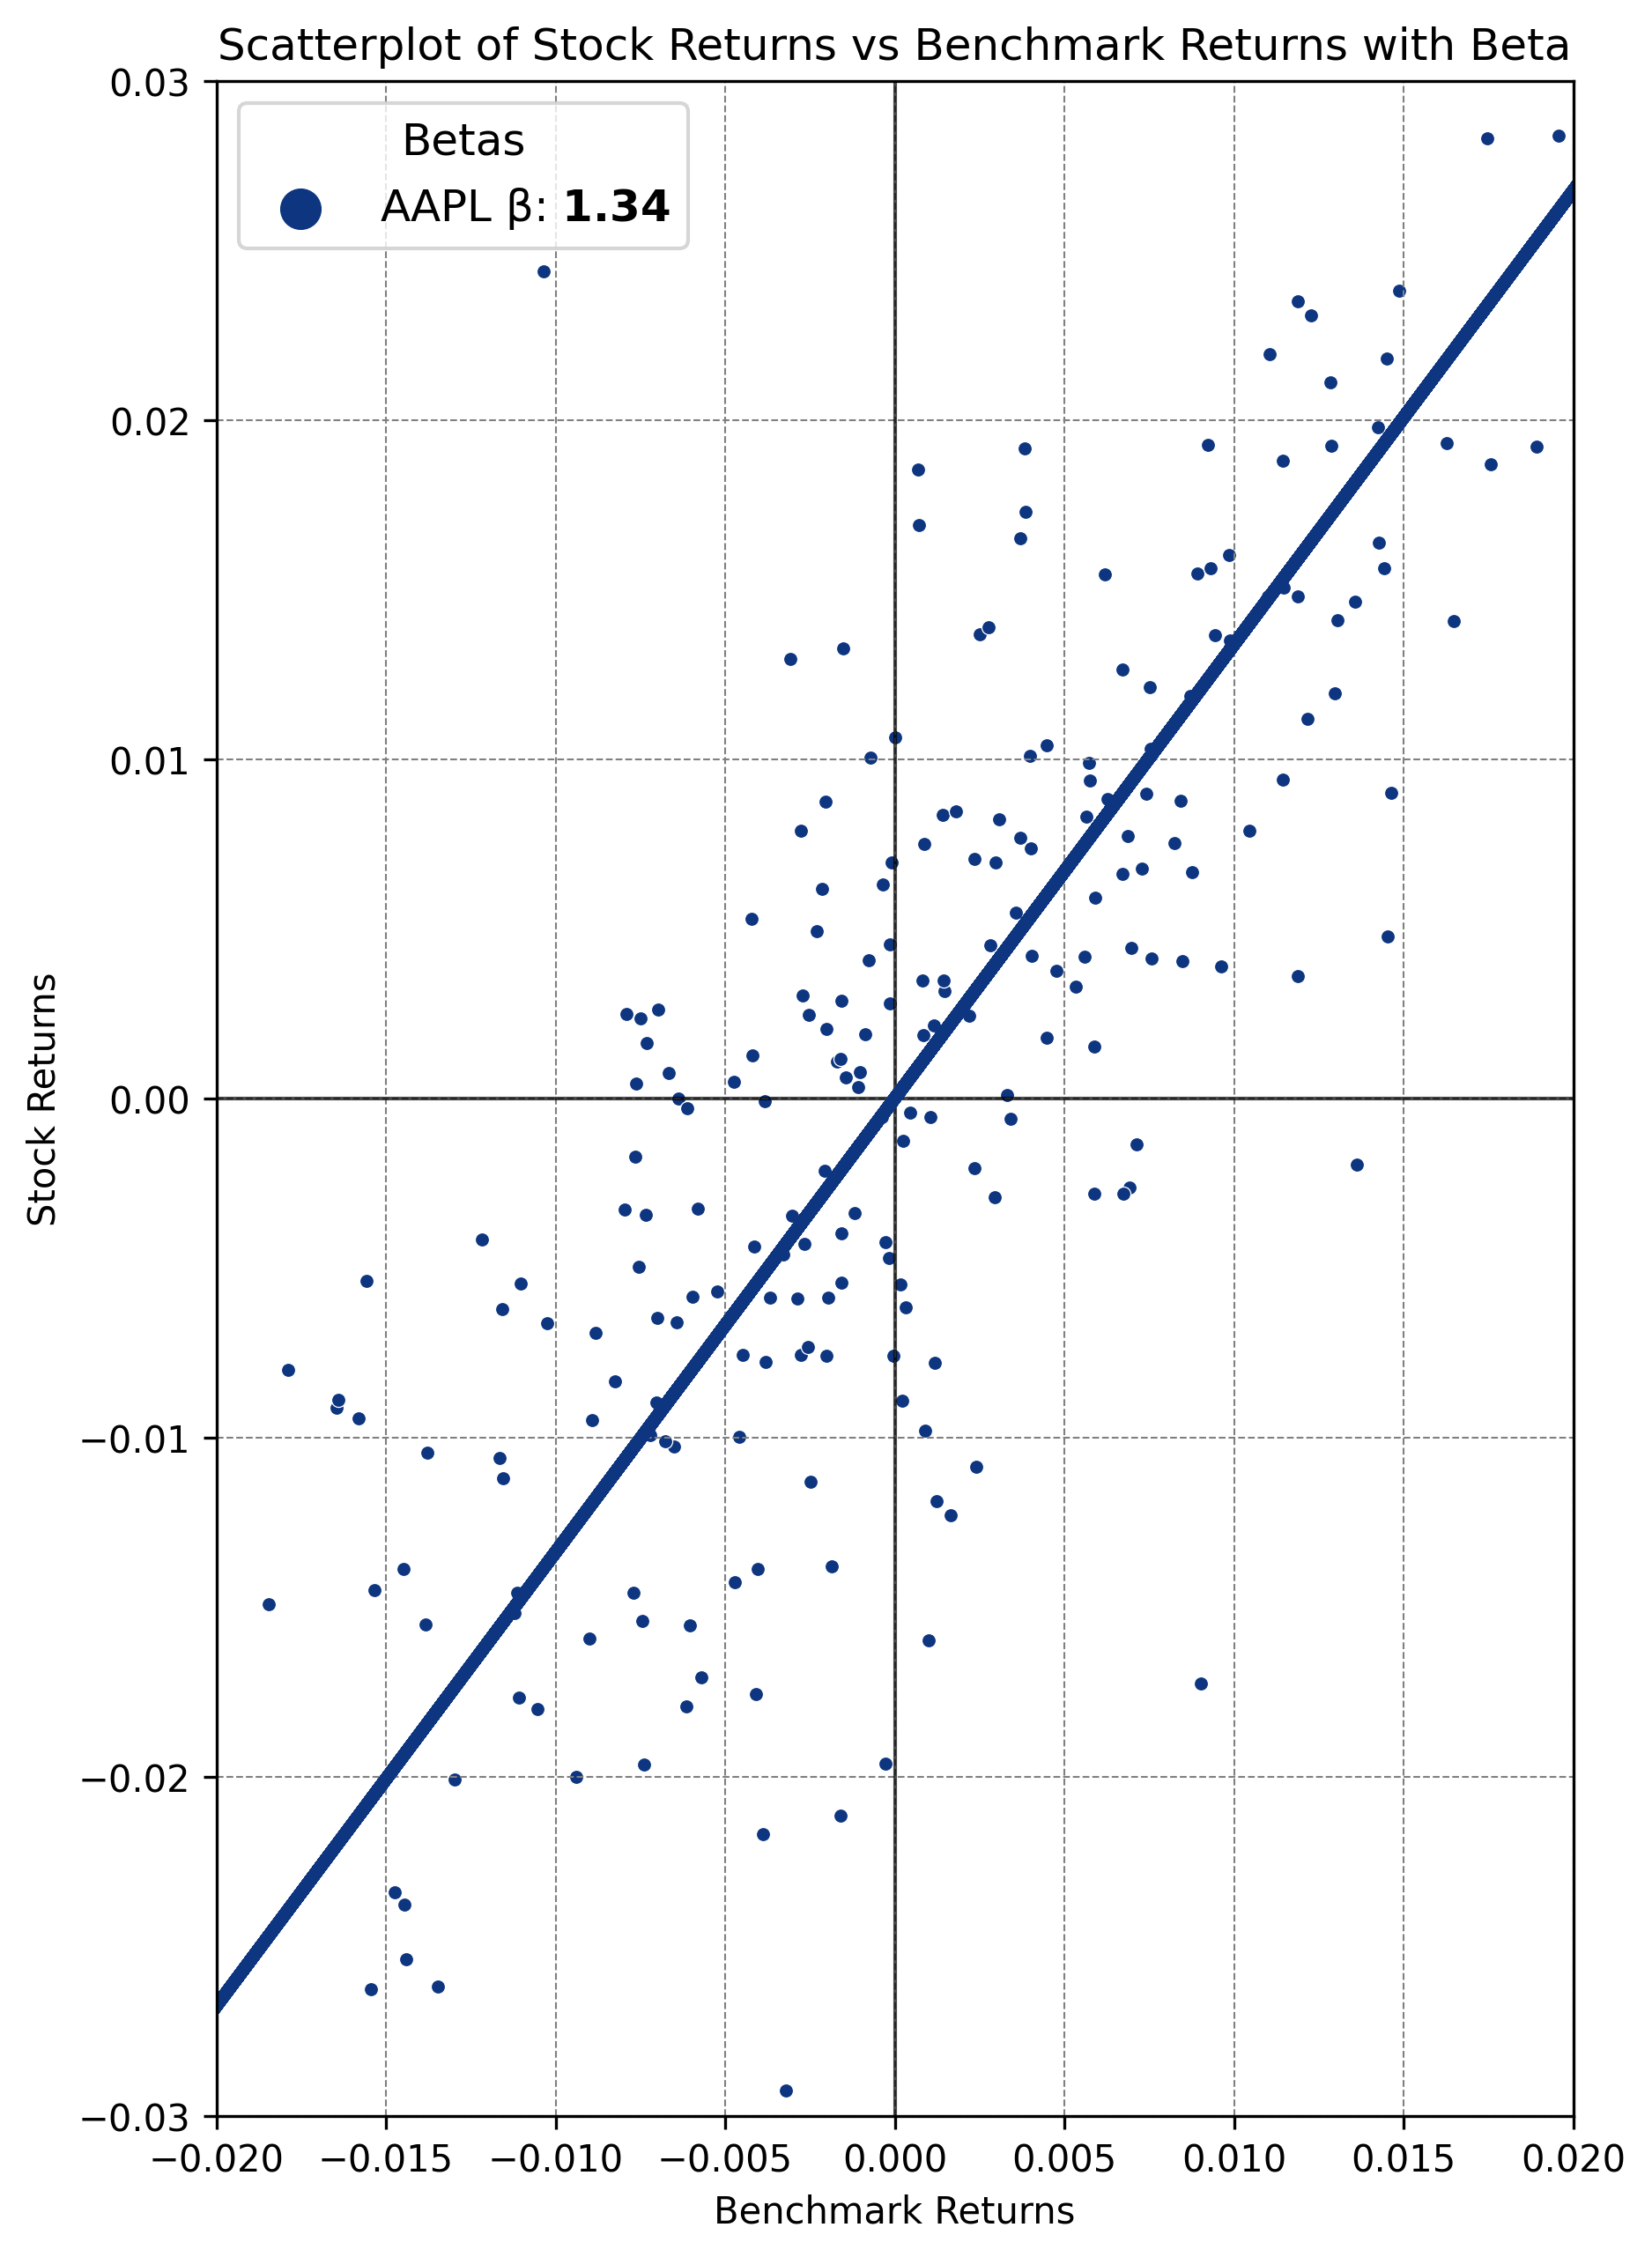

In [15]:
from sklearn.linear_model import LinearRegression
import seaborn as sns

colors = ["#0D3580", "#AF0C15", "#0D7036", "#FFD700", "c", "m"]

# Fetch historical stock data
stock_data = yf.download(tickers + [benchmark], start=start_date, end=end_date)['Adj Close']

# Calculate returns for stocks and benchmark
returns = stock_data.pct_change().dropna()

# Extract benchmark returns
benchmark_returns = returns[benchmark]

# Prepare the DataFrame for betas
beta_data = pd.DataFrame(index=tickers, columns=['Beta'])

# Visualize and compare betas
fig, ax = plt.subplots(figsize=(10, 10),
                       dpi=300)

# Set gridlines
ax.grid(color='gray', linestyle='--', linewidth=0.5,)
ax.axhline(0, color='black', linewidth=1, linestyle='-',alpha=0.7)
ax.axvline(0, color='black', linewidth=1, linestyle='-',alpha=0.7)

for ticker, color in zip(tickers, colors):
    # Extract stock returns
    stock_returns = returns[ticker]
    
    # Combine returns into a DataFrame
    data = pd.concat([stock_returns, benchmark_returns], axis=1)
    data.columns = ['Stock Returns', 'Benchmark Returns']
    
    # Drop NaN values
    data.dropna(inplace=True)
    
    # Fit linear regression
    model = LinearRegression()
    model.fit(data[['Benchmark Returns']], data['Stock Returns'])
    
    # Extract beta coefficient
    beta = model.coef_[0]
    
    # Add beta to beta_data
    beta_data.loc[ticker, 'Beta'] = beta
    # Plot scatterplot
    sns.scatterplot(x='Benchmark Returns', 
                    y='Stock Returns', 
                    data=data, 
                    ax=ax, 
                    label=f'{ticker} β: $\\bf{{ {beta_data.loc[ticker, "Beta"]:0.2f} }}$',
                    color=color,
                    s=15,
                    )
    
    # Plot regression line
    ax.plot(data['Benchmark Returns'], 
            model.predict(data[['Benchmark Returns']]), 
            color=color, 
            linestyle='-', 
            linewidth=3.5,
            )

# Set equal scaling for both axes
ax.set_aspect('equal', 'box')

# Set labels and title
ax.legend(fontsize='large', 
          loc='upper left', 
          title='Betas', 
          title_fontsize='large',
          markerscale=3,
          )
ax.set_xlabel('Benchmark Returns')
ax.set_ylabel('Stock Returns')
ax.set_title('Scatterplot of Stock Returns vs Benchmark Returns with Beta')
ax.set_xlim(-0.02, 0.02)
ax.set_ylim(-0.03, 0.03)